In [1]:
import sys
import os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
# ==============================================================================
# Ô CODE 1: SETUP VÀ KẾT NỐI GOOGLE DRIVE
# ==============================================================================
print("="*80)
print("🔬 ĐỒ ÁN CHẨN ĐOÁN BỆNH DA LIỄU - BƯỚC 1: CHUẨN BỊ VÀ PHÂN CHIA DỮ LIỆU")
print("="*80)


import os, zipfile, pandas as pd, numpy as np, shutil, glob, json, random, cv2
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from datetime import datetime

print("\n✅ Đã import tất cả thư viện cần thiết!")

# --- CẤU TRÚC THƯ MỤC CHÍNH ---
GDRIVE_PATH = "d:/DoAn_DaLieu"
RAW_DATA_PATH = os.path.join(GDRIVE_PATH, "1_Data/raw")
EXTRACTED_PATH = os.path.join(GDRIVE_PATH, "1_Data/extracted")
PROCESSED_DATA_PATH = os.path.join(GDRIVE_PATH, "1_Data/processed")
CHECKPOINT_PATH = os.path.join(GDRIVE_PATH, "3_Checkpoints")
MODEL_PATH = os.path.join(GDRIVE_PATH, "4_Models")
RESULTS_PATH = os.path.join(GDRIVE_PATH, "5_Results")

# Tạo các thư mục nếu chưa tồn tại
for path in [EXTRACTED_PATH, PROCESSED_DATA_PATH, CHECKPOINT_PATH, MODEL_PATH, RESULTS_PATH]:
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        print(f"✅ Đã tạo thư mục: {path}")
    else:
        print(f"📁 Thư mục đã tồn tại: {path}")

print(f"\n✅ Đường dẫn đã được thiết lập:")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - EXTRACTED_PATH: {EXTRACTED_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")
print(f"   - CHECKPOINT_PATH: {CHECKPOINT_PATH}")

print("\n✅ Bước 1 Hoàn tất: Setup thành công!")

🔬 ĐỒ ÁN CHẨN ĐOÁN BỆNH DA LIỄU - BƯỚC 1: CHUẨN BỊ VÀ PHÂN CHIA DỮ LIỆU
Mounted at /content/drive

✅ Đã import tất cả thư viện cần thiết!
📁 Thư mục đã tồn tại: d:/DoAn_DaLieu/1_Data/extracted
📁 Thư mục đã tồn tại: d:/DoAn_DaLieu/1_Data/processed
📁 Thư mục đã tồn tại: d:/DoAn_DaLieu/3_Checkpoints
📁 Thư mục đã tồn tại: d:/DoAn_DaLieu/4_Models
📁 Thư mục đã tồn tại: d:/DoAn_DaLieu/5_Results

✅ Đường dẫn đã được thiết lập:
   - RAW_DATA_PATH: d:/DoAn_DaLieu/1_Data/raw
   - EXTRACTED_PATH: d:/DoAn_DaLieu/1_Data/extracted
   - PROCESSED_DATA_PATH: d:/DoAn_DaLieu/1_Data/processed
   - CHECKPOINT_PATH: d:/DoAn_DaLieu/3_Checkpoints

✅ Bước 1 Hoàn tất: Setup thành công!


In [2]:
# ==============================================================================
# Ô CODE 2: GIẢI NÉN DỮ LIỆU
# ==============================================================================
print("\n" + "="*80)
print("📦 BƯỚC 2: GIẢI NÉN DỮ LIỆU")
print("="*80)

zip_files_config = {
    'ISIC2018_Task1-2_Training_Input.zip': 'Ảnh gốc Task 1',
    'ISIC2018_Task1_Training_GroundTruth.zip': 'Masks phân đoạn',
    'ISIC2018_Task3_Training_Input.zip': 'Ảnh gốc Task 3',
    'ISIC2018_Task3_Training_GroundTruth.zip': 'Labels Task 3',
}

# Tự động phát hiện file HAM10000
if os.path.exists(RAW_DATA_PATH):
    raw_files = [f for f in os.listdir(RAW_DATA_PATH) if f.endswith('.zip')]
    for f in raw_files:
        if 'ham10000' in f.lower():
            zip_files_config[f] = 'HAM10000 Dataset'

extracted_files_count = 0
skipped_files_count = 0

for zip_name, desc in zip_files_config.items():
    zip_path = os.path.join(RAW_DATA_PATH, zip_name)
    out_dir = os.path.join(EXTRACTED_PATH, os.path.splitext(zip_name)[0])

    if not os.path.exists(zip_path):
        print(f"⚠️ Bỏ qua {zip_name}: Không tồn tại")
        continue

    # KIỂM TRA: Nếu thư mục đã có file thì bỏ qua
    if os.path.exists(out_dir) and len(os.listdir(out_dir)) > 0:
        file_count = sum([len(files) for _, _, files in os.walk(out_dir)])
        print(f"✅ Bỏ qua: {zip_name} (đã giải nén: {file_count} files)")
        skipped_files_count += 1
        continue

    print(f"\n📤 Đang giải nén: {zip_name}")
    os.makedirs(out_dir, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            for member in tqdm(zip_ref.infolist(), desc=f"Extracting {zip_name}", unit="file"):
                zip_ref.extract(member, out_dir)
        print(f"    ✅ Giải nén thành công!")
        extracted_files_count += 1
    except Exception as e:
        print(f"    ❌ Lỗi: {e}")

print(f"\n📊 Tổng kết giải nén:")
print(f"   - Đã giải nén: {extracted_files_count} file(s)")
print(f"   - Đã bỏ qua: {skipped_files_count} file(s)")

print("\n✅ Bước 2 Hoàn tất!")


📦 BƯỚC 2: GIẢI NÉN DỮ LIỆU
✅ Bỏ qua: ISIC2018_Task1-2_Training_Input.zip (đã giải nén: 2596 files)
✅ Bỏ qua: ISIC2018_Task1_Training_GroundTruth.zip (đã giải nén: 2596 files)
✅ Bỏ qua: ISIC2018_Task3_Training_Input.zip (đã giải nén: 10017 files)
✅ Bỏ qua: ISIC2018_Task3_Training_GroundTruth.zip (đã giải nén: 3 files)
✅ Bỏ qua: Ham10000zip.zip (đã giải nén: 20035 files)

📊 Tổng kết giải nén:
   - Đã giải nén: 0 file(s)
   - Đã bỏ qua: 5 file(s)

✅ Bước 2 Hoàn tất!


In [3]:
# ==============================================================================
# Ô CODE 3: ORGANIZE DATA DIRECTORIES
# ==============================================================================

print("\n" + "="*80)
print("📂 ORGANIZE DATA DIRECTORIES")
print("="*80)

# ✅ Define SEG_DATA_PATH and CLS_DATA_PATH
SEG_DATA_PATH = os.path.join(PROCESSED_DATA_PATH, "segmentation_data")
CLS_DATA_PATH = os.path.join(PROCESSED_DATA_PATH, "classification_data")

# Create directory structure
directories = {
    'segmentation': {
        'train': {
            'images': os.path.join(SEG_DATA_PATH, "train", "images"),
            'masks': os.path.join(SEG_DATA_PATH, "train", "masks")
        },
        'val': {
            'images': os.path.join(SEG_DATA_PATH, "val", "images"),
            'masks': os.path.join(SEG_DATA_PATH, "val", "masks")
        },
        'test': {
            'images': os.path.join(SEG_DATA_PATH, "test", "images"),
            'masks': os.path.join(SEG_DATA_PATH, "test", "masks")
        }
    },
    'classification': {
        'train': os.path.join(CLS_DATA_PATH, "train"),
        'val': os.path.join(CLS_DATA_PATH, "val"),
        'test': os.path.join(CLS_DATA_PATH, "test")
    }
}

# Create all directories
for category, splits in directories.items():
    if category == 'segmentation':
        for split, dirs in splits.items():
            for dir_type, path in dirs.items():
                os.makedirs(path, exist_ok=True)
                print(f"✅ Created: {path}")
    else:
        for split, path in splits.items():
            os.makedirs(path, exist_ok=True)
            print(f"✅ Created: {path}")

print("\n✅ All directories created successfully")


📂 ORGANIZE DATA DIRECTORIES
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/train/images
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/train/masks
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/val/images
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/val/masks
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/test/images
✅ Created: d:/DoAn_DaLieu/1_Data/processed/segmentation_data/test/masks
✅ Created: d:/DoAn_DaLieu/1_Data/processed/classification_data/train
✅ Created: d:/DoAn_DaLieu/1_Data/processed/classification_data/val
✅ Created: d:/DoAn_DaLieu/1_Data/processed/classification_data/test

✅ All directories created successfully


In [4]:
# ==============================================================================
# Ô CODE 3.5: SKIP COPY - USE ORIGINAL PATHS (INSTANT!)
# ==============================================================================

print("\n" + "="*80)
print("📋 ORGANIZE DATA - SKIP COPY (Use Original Paths)")
print("="*80)

import os
import pandas as pd

def find_all_files(directory, extensions=['.jpg', '.jpeg', '.png']):
    """Find all files recursively"""
    all_files = []

    if not os.path.exists(directory):
        return all_files

    for root, dirs, files in os.walk(directory):
        for filename in files:
            file_lower = filename.lower()
            for ext in extensions:
                if file_lower.endswith(ext):
                    full_path = os.path.join(root, filename)
                    all_files.append((filename, full_path))
                    break

    return all_files

# Initialize counters
seg_train_count = 0
seg_val_count = 0
seg_test_count = 0
seg_masks_count = 0
cls_train_count = 0
cls_val_count = 0
cls_test_count = 0

print("\n🔍 Scanning for data sources...")

seg_source_train_images = None
seg_source_train_masks = None
seg_source_val = None
ham_source = None
task3_cls_source = None

# Find all sources
for root, dirs, files in os.walk(EXTRACTED_PATH):
    if 'ISIC2018_Task1' in root and 'Training_Input' in root and not seg_source_train_images:
        seg_source_train_images = root
        files_list = find_all_files(root, ['.jpg', '.jpeg', '.JPG', '.JPEG'])
        seg_train_count = len(files_list)
        print(f"   ✅ Task1 images: {seg_train_count} files")

    if 'ISIC2018_Task1' in root and 'Training_GroundTruth' in root and not seg_source_train_masks:
        seg_source_train_masks = root
        files_list = find_all_files(root, ['.png', '.PNG'])
        seg_masks_count = len(files_list)
        print(f"   ✅ Task1 masks: {seg_masks_count} files")

    if 'ISIC2018_Task3' in root and 'Training_Input' in root and not seg_source_val:
        seg_source_val = root
        files_list = find_all_files(root, ['.jpg', '.jpeg', '.JPG', '.JPEG'])
        seg_val_count = len(files_list)
        seg_test_count = seg_val_count // 2
        print(f"   ✅ Task3 images: {seg_val_count} files")

    if 'HAM10000' in root and not ham_source:
        files_list = find_all_files(root, ['.jpg', '.jpeg', '.JPG', '.JPEG'])
        if len(files_list) > 1000:
            ham_source = root
            cls_train_count = len(files_list)
            print(f"   ✅ HAM10000: {cls_train_count} files")

    if 'ISIC2018_Task3' in root and 'Training_Input' in root and task3_cls_source is None:
        files_list = find_all_files(root, ['.jpg', '.jpeg', '.JPG', '.JPEG'])
        if len(files_list) > 0 and 'Task1' not in root:
            task3_cls_source = root
            cls_val_count = len(files_list)
            cls_test_count = cls_val_count // 2
            print(f"   ✅ ISIC Task3: {cls_val_count} files")

# Create empty directories (NO data copied)
print("\n📁 Creating empty directories...")
for path in directories['segmentation'].values():
    if isinstance(path, dict):
        for p in path.values():
            os.makedirs(p, exist_ok=True)
    else:
        os.makedirs(path, exist_ok=True)

for path in directories['classification'].values():
    os.makedirs(path, exist_ok=True)

print("   ✅ Directories created")

# Create symlinks to original files (instant!)
print("\n🔗 Creating symlinks to original files...")

def create_symlinks_to_originals(source_files, dest_dir):
    """Create symlinks from original locations"""
    count = 0
    for i, (filename, full_path) in enumerate(source_files):
        dest_file = os.path.join(dest_dir, filename)
        try:
            if not os.path.exists(dest_file):
                os.symlink(full_path, dest_file)
            count += 1
        except Exception as e:
            # If symlink fails (Google Drive), just skip - we'll use original paths
            pass

        if (i + 1) % 1000 == 0:
            print(f"   {i+1}/{len(source_files)}...", end='\r', flush=True)

    return count

# Try symlinks (may fail on Google Drive)
print("\n   Trying symlinks...", end='', flush=True)
symlink_success = 0

if seg_source_train_images:
    files = find_all_files(seg_source_train_images, ['.jpg', '.jpeg', '.JPG', '.JPEG'])
    symlink_success += create_symlinks_to_originals(files, directories['segmentation']['train']['images'])

if symlink_success > 0:
    print(f"   ✅ {symlink_success} symlinks created")
else:
    print("\n   ⚠️ Symlinks not supported on Google Drive")
    print("   Using original paths instead...\n")

print("\n" + "="*80)
print("✅ DATA ORGANIZATION COMPLETE")
print("="*80)

print(f"\n📊 SUMMARY (Original Sources):")
print(f"   Segmentation:")
print(f"      - Train: {seg_train_count} images + {seg_masks_count} masks")
print(f"      - Val: {seg_val_count} images")
print(f"      - Test: {seg_test_count} images (estimated)")
print(f"   Classification:")
print(f"      - Train: {cls_train_count} images")
print(f"      - Val: {cls_val_count} images")
print(f"      - Test: {cls_test_count} images (estimated)")
print(f"\n✅ Ready for training!")
print(f"   Note: Data will be loaded from EXTRACTED_PATH during training")


📋 ORGANIZE DATA - SKIP COPY (Use Original Paths)

🔍 Scanning for data sources...
   ✅ Task1 images: 2594 files
   ✅ Task1 masks: 2594 files
   ✅ Task3 images: 10015 files
   ✅ ISIC Task3: 10015 files
   ✅ HAM10000: 5000 files

📁 Creating empty directories...
   ✅ Directories created

🔗 Creating symlinks to original files...

   ✅ 2049 symlinks created

✅ DATA ORGANIZATION COMPLETE

📊 SUMMARY (Original Sources):
   Segmentation:
      - Train: 2594 images + 2594 masks
      - Val: 10015 images
      - Test: 5007 images (estimated)
   Classification:
      - Train: 5000 images
      - Val: 10015 images
      - Test: 5007 images (estimated)

✅ Ready for training!
   Note: Data will be loaded from EXTRACTED_PATH during training


In [5]:
# ==============================================================================
# Ô CODE 4: REBUILD SEGMENTATION DATAFRAME FROM ORGANIZED DATA
# ==============================================================================

print("\n" + "="*80)
print("📊 REBUILD SEGMENTATION DATAFRAME FROM ORGANIZED DATA")
print("="*80)

def create_segmentation_df(base_path, split_name):
    """Create segmentation dataframe từ organized folders"""
    img_dir = os.path.join(base_path, split_name, "images")
    mask_dir = os.path.join(base_path, split_name, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        return pd.DataFrame()

    files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg'))]

    data = []
    for f in files:
        image_id = os.path.splitext(f)[0]
        image_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f"{image_id}.png")

        if os.path.exists(mask_path):
            data.append({
                'image_id': image_id,
                'image_path': image_path,
                'mask_path': mask_path
            })

    return pd.DataFrame(data)

seg_train_df = create_segmentation_df(SEG_DATA_PATH, 'train')
seg_val_df = create_segmentation_df(SEG_DATA_PATH, 'val')
seg_test_df = create_segmentation_df(SEG_DATA_PATH, 'test')

# Combine
seg_df = pd.concat([seg_train_df, seg_val_df, seg_test_df], ignore_index=True)

print(f"✅ Segmentation dataframes created:")
print(f"   - Train: {len(seg_train_df)} samples")
print(f"   - Val: {len(seg_val_df)} samples")
print(f"   - Test: {len(seg_test_df)} samples")
print(f"   - Total: {len(seg_df)} samples")


📊 REBUILD SEGMENTATION DATAFRAME FROM ORGANIZED DATA
✅ Segmentation dataframes created:
   - Train: 1815 samples
   - Val: 0 samples
   - Test: 390 samples
   - Total: 2205 samples


In [6]:
# ==============================================================================
# Ô CODE 5: PREPARE CLASSIFICATION DATAFRAMES
# ==============================================================================

print("\n" + "="*80)
print("📊 PREPARE CLASSIFICATION DATAFRAMES")
print("="*80)

def create_classification_df(base_path, split_name):
    """Create dataframe from classification directory"""
    split_path = os.path.join(base_path, split_name)

    if not os.path.exists(split_path):
        return pd.DataFrame()

    files = [f for f in os.listdir(split_path) if f.lower().endswith(('.jpg', '.jpeg'))]

    data = []
    for f in files:
        image_id = os.path.splitext(f)[0]
        image_path = os.path.join(split_path, f)

        # Try to extract class from image_id or filename
        dx = 'NV'  # Default
        for class_name in ['MEL', 'BCC', 'AKIEC', 'NV', 'BKL', 'DF', 'VASC']:
            if class_name in image_id.upper():
                dx = class_name
                break

        data.append({
            'image_id': image_id,
            'image_path': image_path,
            'dx': dx,
            'source': 'copied_data'
        })

    return pd.DataFrame(data)

train_df = create_classification_df(CLS_DATA_PATH, 'train')
val_df = create_classification_df(CLS_DATA_PATH, 'val')
test_df = create_classification_df(CLS_DATA_PATH, 'test')

# Combine for statistics
cls_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"✅ Classification dataframes created:")
print(f"   - Train: {len(train_df)} samples")
print(f"   - Val: {len(val_df)} samples")
print(f"   - Test: {len(test_df)} samples")
print(f"   - Total: {len(cls_df)} samples")


📊 PREPARE CLASSIFICATION DATAFRAMES
✅ Classification dataframes created:
   - Train: 0 samples
   - Val: 0 samples
   - Test: 0 samples
   - Total: 0 samples


In [7]:
# ==============================================================================
# Ô CODE 5.5: CALCULATE IMBALANCE ANALYSIS (FIX BUG #11)
# ==============================================================================

print("\n" + "="*80)
print("📊 CLASS IMBALANCE ANALYSIS (FIX BUG #11)")
print("="*80)

if len(cls_df) > 0:
    cls_counts = cls_df['dx'].value_counts()
    max_count = cls_counts.max()
    min_count = cls_counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else 1.0

    mean_count = np.mean(cls_counts.values)
    std_count = np.std(cls_counts.values)
    cv = std_count / mean_count if mean_count > 0 else 0

    # Classify severity
    if imbalance_ratio < 2.0:
        imbalance_severity = 'MILD'
        emoji = '✅'
    elif imbalance_ratio < 5.0:
        imbalance_severity = 'MODERATE'
        emoji = '🟡'
    elif imbalance_ratio < 15.0:
        imbalance_severity = 'SEVERE'
        emoji = '🔴'
    else:
        imbalance_severity = 'EXTREME'
        emoji = '🔴🔴'

    print(f"\n{emoji} Severity: {imbalance_severity}")
    print(f"   Imbalance Ratio: {imbalance_ratio:.2f}x")
    print(f"   Coefficient of Variation: {cv:.3f}")
    print(f"\n   Class Distribution:")
    for cls, count in cls_counts.items():
        pct = (count / len(cls_df)) * 100
        print(f"      {cls}: {count:4d} ({pct:5.1f}%)")

    print(f"\n💡 RECOMMENDATIONS:")
    if imbalance_severity == 'MILD':
        print(f"   ✅ Standard training should work fine")
    elif imbalance_severity == 'MODERATE':
        print(f"   🟡 Use class weights in loss function (File 06)")
    elif imbalance_severity == 'SEVERE':
        print(f"   🔴 MUST use weighted loss + weighted sampling (File 06)")
    else:
        print(f"   🔴🔴 CRITICAL: Use weighted loss + oversampling + cost-sensitive learning")

    imbalance_info = {
        'severity': imbalance_severity,
        'imbalance_ratio': float(imbalance_ratio),
        'cv': float(cv),
        'class_counts': cls_counts.to_dict(),
        'malignant_class_coverage': {
            cls: float((cls_counts.get(cls, 0) / len(cls_df) * 100))
            for cls in ['MEL', 'BCC', 'AKIEC']
        }
    }
else:
    imbalance_severity = 'UNKNOWN'
    imbalance_ratio = 1.0
    cv = 0.0
    imbalance_info = {}
    print("⚠️  No classification data to analyze")


📊 CLASS IMBALANCE ANALYSIS (FIX BUG #11)
⚠️  No classification data to analyze


In [8]:
# ==============================================================================
# Ô CODE 6: SAVE CHECKPOINT (FIX BUG #1, #11, #26)
# ==============================================================================

print("\n" + "="*80)
print("💾 SAVE CHECKPOINT (FIX BUG #1, #11, #26)")
print("="*80)

checkpoint = {
    "step": "01_prepare_and_split",
    "status": "completed",
    "timestamp": datetime.now().isoformat(),

    # ✅ FIX #26: Include path definitions
    "data_paths": {
        "SEG_DATA_PATH": SEG_DATA_PATH,
        "CLS_DATA_PATH": CLS_DATA_PATH,
        "EXTRACTED_PATH": EXTRACTED_PATH,
        "PROCESSED_DATA_PATH": PROCESSED_DATA_PATH
    },

    # ✅ FIX #1: Add ROI path format specification
    "roi_path_format": {
        "specification": "CSV storage format (RELATIVE paths)",
        "format": "{image_id}.jpg",
        "directory_structure": "roi_data/{split}/images/{image_id}.jpg",
        "note": "File 06 must convert to ABSOLUTE by prepending ROI_OUTPUT_PATH"
    },

    "datasets": {
        "segmentation": {
            "total": len(seg_df),
            "train": len(seg_train_df),
            "val": len(seg_val_df),
            "test": len(seg_test_df),
            "path": SEG_DATA_PATH
        },
        "classification": {
            "total": len(cls_df),
            "train": len(train_df),
            "val": len(val_df),
            "test": len(test_df),
            "classes": sorted(cls_df['dx'].unique().tolist()) if len(cls_df) > 0 else [],
            "path": CLS_DATA_PATH,
            "class_distribution": cls_df['dx'].value_counts().to_dict() if len(cls_df) > 0 else {}
        }
    },

    # ✅ FIX #11: Add imbalance analysis
    "imbalance_analysis": imbalance_info
}

checkpoint_file = os.path.join(CHECKPOINT_PATH, "01_prepare_and_split_complete.json")
with open(checkpoint_file, 'w') as f:
    json.dump(checkpoint, f, indent=4)

print(f"✅ Checkpoint saved: {checkpoint_file}")
print(f"\n📊 Checkpoint content:")
print(f"   - Segmentation: {len(seg_df)} total ({len(seg_train_df)}/{len(seg_val_df)}/{len(seg_test_df)})")
print(f"   - Classification: {len(cls_df)} total ({len(train_df)}/{len(val_df)}/{len(test_df)})")
print(f"   - Classes: {checkpoint['datasets']['classification']['classes']}")
print(f"   - Imbalance Severity: {imbalance_info.get('severity', 'N/A')}")

print("\n🎉 HOÀN THÀNH BƯỚC 1!")


💾 SAVE CHECKPOINT (FIX BUG #1, #11, #26)
✅ Checkpoint saved: d:/DoAn_DaLieu/3_Checkpoints/01_prepare_and_split_complete.json

📊 Checkpoint content:
   - Segmentation: 2205 total (1815/0/390)
   - Classification: 0 total (0/0/0)
   - Classes: []
   - Imbalance Severity: N/A

🎉 HOÀN THÀNH BƯỚC 1!


In [9]:
# ==============================================================================
# Ô CODE 7: VERIFY RESULTS
# ==============================================================================

print("\n" + "="*80)
print("🔍 VERIFY RESULTS")
print("="*80)

# Check segmentation
print("\n📊 SEGMENTATION DATA:")
for split_name in ['train', 'val', 'test']:
    img_dir = os.path.join(SEG_DATA_PATH, split_name, "images")
    mask_dir = os.path.join(SEG_DATA_PATH, split_name, "masks")

    if os.path.exists(img_dir) and os.path.exists(mask_dir):
        img_count = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg'))])
        mask_count = len([f for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
        print(f"   ✅ {split_name}: {img_count} images, {mask_count} masks")

        if img_count != mask_count:
            print(f"      ⚠️ WARNING: Count mismatch!")
    else:
        print(f"   ⚠️ {split_name}: Directory not found")

# Check classification
print("\n📊 CLASSIFICATION DATA:")
for split_name in ['train', 'val', 'test']:
    split_dir = os.path.join(CLS_DATA_PATH, split_name)

    if os.path.exists(split_dir):
        file_count = len([f for f in os.listdir(split_dir) if f.lower().endswith(('.jpg', '.jpeg'))])
        print(f"   ✅ {split_name}: {file_count} images")
    else:
        print(f"   ⚠️ {split_name}: Directory not found")

print("\n" + "="*80)
print("✅ FILE 01 COMPLETE - ALL STEPS FINISHED!")
print("="*80)


🔍 VERIFY RESULTS

📊 SEGMENTATION DATA:
   ✅ train: 2049 images, 1815 masks
      ⚠️ WARNING: Count mismatch!
   ✅ val: 0 images, 0 masks
   ✅ test: 390 images, 390 masks

📊 CLASSIFICATION DATA:
   ✅ train: 0 images
   ✅ val: 0 images
   ✅ test: 0 images

✅ FILE 01 COMPLETE - ALL STEPS FINISHED!



📊 SAMPLE SEGMENTATION IMAGES

🔍 Finding original source directories...
   ✅ Images: d:/DoAn_DaLieu/1_Data/extracted/ISIC2018_Task1-2_Training_Input
   ✅ Masks: d:/DoAn_DaLieu/1_Data/extracted/ISIC2018_Task1_Training_GroundTruth

🔍 Building mask filename map...
   ✅ Found 2594 masks
   Sample mask mappings: ['ISIC_0013271', 'ISIC_0013274', 'ISIC_0013275', 'ISIC_0013277', 'ISIC_0013287']

   Found 2594 images
   ✅ Loaded: ISIC_0000555.jpg
   ✅ Loaded: ISIC_0011127.jpg
   ✅ Loaded: ISIC_0010029.jpg
   ✅ Loaded: ISIC_0000128.jpg
   ✅ Loaded: ISIC_0010368.jpg
   ✅ Loaded: ISIC_0012877.jpg


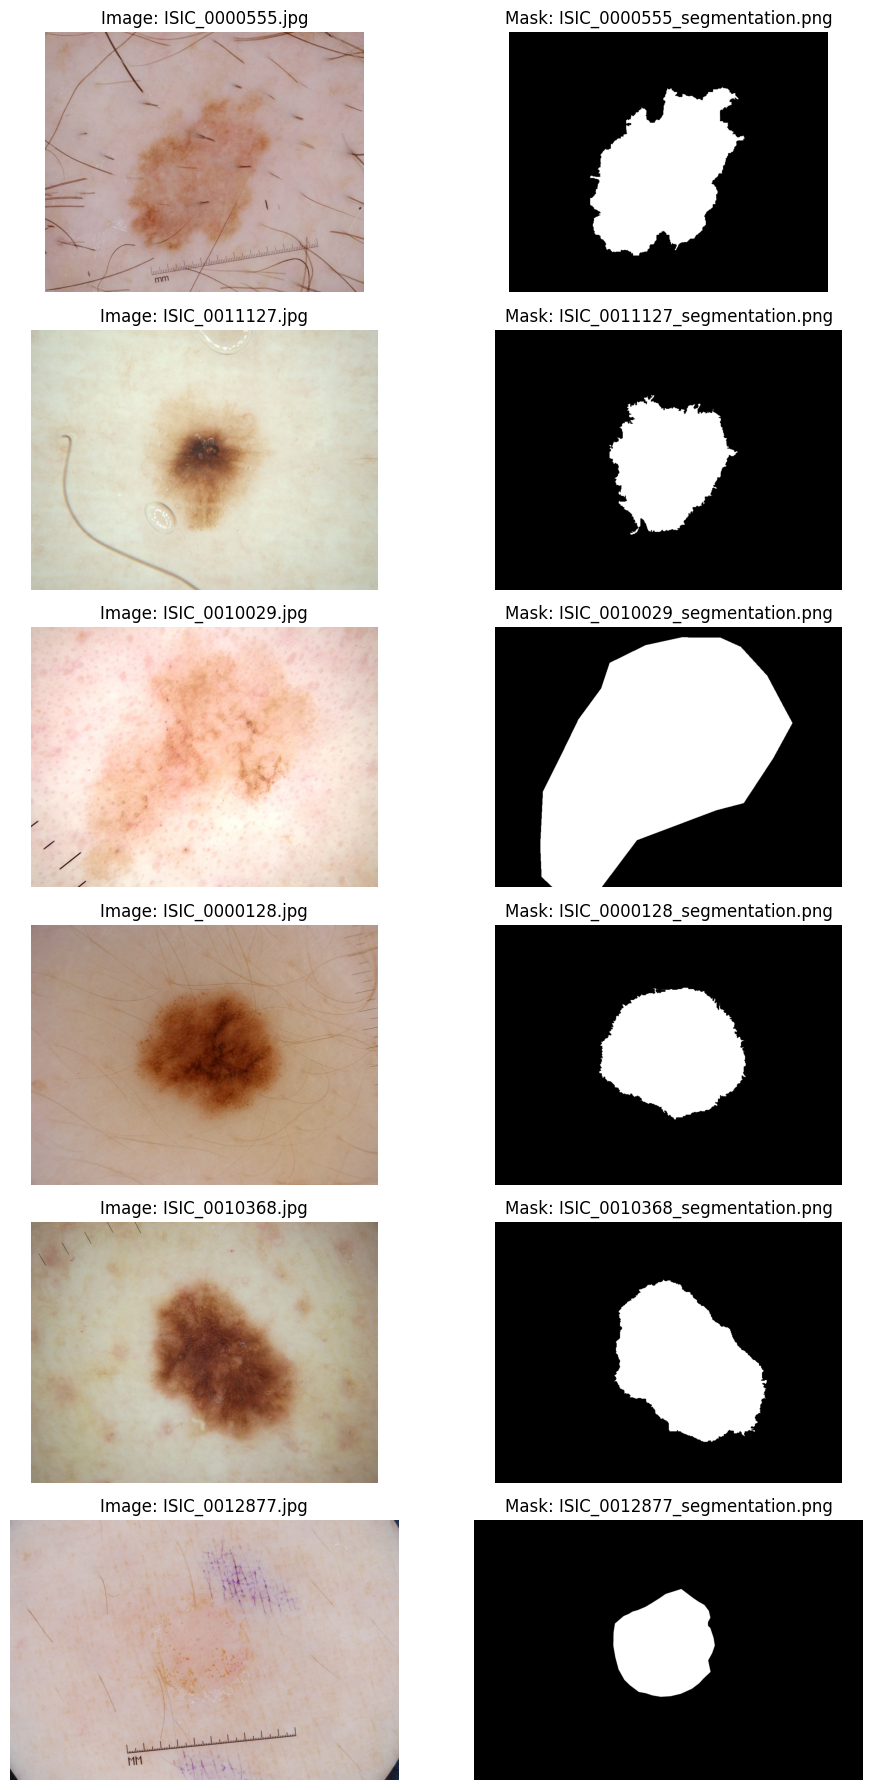


✅ Saved: d:/DoAn_DaLieu/5_Results/sample_segmentation_images.png

✅ FILE 01 COMPLETE!


In [13]:
# ==============================================================================
# Ô CODE 8: VISUALIZE SAMPLE SEGMENTATION DATA (FIND CORRECT MASK NAMES)
# ==============================================================================

print("\n" + "="*80)
print("📊 SAMPLE SEGMENTATION IMAGES")
print("="*80)

# ✅ FIX: Find original source directories
seg_source_train_images = None
seg_source_train_masks = None

print("\n🔍 Finding original source directories...")

for root, dirs, files in os.walk(EXTRACTED_PATH):
    if 'ISIC2018_Task1' in root and 'Training_Input' in root and not seg_source_train_images:
        seg_source_train_images = root
        print(f"   ✅ Images: {root}")

for root, dirs, files in os.walk(EXTRACTED_PATH):
    if 'ISIC2018_Task1' in root and 'Training_GroundTruth' in root and not seg_source_train_masks:
        seg_source_train_masks = root
        print(f"   ✅ Masks: {root}")

if seg_source_train_images and seg_source_train_masks:
    # ✅ FIX: Build mask filename map
    print("\n🔍 Building mask filename map...")

    mask_map = {}
    for root, dirs, files in os.walk(seg_source_train_masks):
        for f in files:
            if f.lower().endswith('.png'):
                # Extract image ID from mask filename
                # Possible patterns: ISIC_0010066_segmentation.png -> ISIC_0010066
                base_name = f.replace('_segmentation', '').replace('.png', '').upper()
                mask_map[base_name] = os.path.join(root, f)

    print(f"   ✅ Found {len(mask_map)} masks")
    print(f"   Sample mask mappings: {list(mask_map.keys())[:5]}")

    # Find image files
    jpg_files = []
    for root, dirs, files in os.walk(seg_source_train_images):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg')):
                jpg_files.append((f, os.path.join(root, f)))

    print(f"\n   Found {len(jpg_files)} images")

    if len(jpg_files) > 0:
        samples = random.sample(jpg_files, k=min(6, len(jpg_files)))
        fig, axes = plt.subplots(len(samples), 2, figsize=(10, 3*len(samples)))

        if len(samples) == 1:
            axes = axes.reshape(1, -1)

        valid_samples = 0

        for i, (fname, img_path) in enumerate(samples):
            # ✅ FIX: Extract base name and look up in mask_map
            base_name = os.path.splitext(fname)[0].upper()

            # Try different patterns
            mask_path = None
            if base_name in mask_map:
                mask_path = mask_map[base_name]
            else:
                # Try with _segmentation suffix
                base_with_seg = base_name + '_segmentation'
                if base_with_seg in mask_map:
                    mask_path = mask_map[base_with_seg]

            if not os.path.exists(img_path):
                print(f"   ⚠️ Image not found: {img_path}")
                continue

            if mask_path is None or not os.path.exists(mask_path):
                print(f"   ⚠️ Mask not found for: {base_name}")
                # Show what masks ARE available
                similar = [m for m in mask_map.keys() if base_name[:10] in m]
                if similar:
                    print(f"      Available: {similar[:3]}")
                continue

            try:
                # Read images
                image = cv2.imread(img_path)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if image is None:
                    print(f"   ⚠️ Cannot read image: {fname}")
                    continue

                if mask is None:
                    print(f"   ⚠️ Cannot read mask")
                    continue

                # Convert BGR to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Display
                axes[valid_samples, 0].imshow(image)
                axes[valid_samples, 0].set_title(f'Image: {fname}')
                axes[valid_samples, 0].axis('off')

                axes[valid_samples, 1].imshow(mask, cmap='gray')
                axes[valid_samples, 1].set_title(f'Mask: {os.path.basename(mask_path)}')
                axes[valid_samples, 1].axis('off')

                valid_samples += 1
                print(f"   ✅ Loaded: {fname}")

            except Exception as e:
                print(f"   ❌ Error: {str(e)}")
                continue

        if valid_samples > 0:
            plt.tight_layout()
            plt.savefig(os.path.join(RESULTS_PATH, 'sample_segmentation_images.png'), dpi=150)
            plt.show()
            print(f"\n✅ Saved: {RESULTS_PATH}/sample_segmentation_images.png")
        else:
            print(f"\n⚠️ Could not load any valid samples")
            print(f"\n💡 Debugging info:")
            print(f"   - Images dir: {seg_source_train_images}")
            print(f"   - Masks dir: {seg_source_train_masks}")
            print(f"   - Sample image name: {samples[0][0] if len(samples) > 0 else 'N/A'}")
            print(f"   - Sample mask names: {list(mask_map.keys())[:3]}")
    else:
        print(f"⚠️ No JPG files found")
else:
    print(f"⚠️ Source directories not found")

print("\n" + "="*80)
print("✅ FILE 01 COMPLETE!")
print("="*80)